In [18]:
import scanpy as sc
import os
import argparse
import scvelo as scv

In [5]:
adata = sc.read_h5ad('/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/pbmc68k_preprocessed_20260122.h5ad')
gene_list = list(adata.var["gene_name"].unique())
print(len(gene_list))

1024


## Verification

In [6]:
# Verify the saved data
print("\n=== Verification ===")
print(f"Final data shape: {adata.shape}")
print(f"adata.var columns: {list(adata.var.columns)}")
print(f"'gene_name' column exists in adata.var: {'gene_name' in adata.var.columns}")
print(f"adata.obs columns: {list(adata.obs.columns)}")
print(f"'celltype' column exists in adata.obs: {'celltype' in adata.obs.columns}")
print(f"adata.n_vars (number of genes): {adata.n_vars}")
print(f"adata.n_obs (number of cells): {adata.n_obs}")


=== Verification ===
Final data shape: (68579, 1024)
adata.var columns: ['gene_id', 'gene_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std']
'gene_name' column exists in adata.var: True
adata.obs columns: ['TSNE.1', 'TSNE.2', 'celltype', 'n_genes']
'celltype' column exists in adata.obs: True
adata.n_vars (number of genes): 1024
adata.n_obs (number of cells): 68579


In [35]:
adata.var["gene_name"]

ENSG00000272512    RP11-54O7.17
ENSG00000187608           ISG15
ENSG00000142609        C1orf222
ENSG00000187730           GABRD
ENSG00000225931    RP3-395M20.7
                       ...     
ENSG00000215458     AP001053.11
ENSG00000160224            AIRE
ENSG00000142185           TRPM2
ENSG00000269430         LRRC3DN
ENSG00000160307           S100B
Name: gene_name, Length: 1024, dtype: category
Categories (1024, object): ['AATK', 'ABCA1', 'ABCC3', 'ABHD1', ..., 'ZNF562', 'ZNF618', 'ZNF683', 'hsa-mir-150']

In [7]:
import sys
import torch
import torch.nn as nn

# Add scDiffusion directory to path for importing ODE and guided_diffusion modules
sys.path.insert(0, '/home/suzuki/Projects/scDiffusion')

from guided_diffusion.cell_model import Cell_Unet
from ODE.ode_analysis1106 import GeneODE, ODE_ML_Hybrid

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")



Using device: cuda


### モデルを定義する関数: build_and_load_hybrid_model

In [10]:
import os
import torch
from typing import Any, Dict, Optional, Tuple, Union

def build_and_load_hybrid_model(
    checkpoint_path: str,
    gene_list: list,
    edge_tsv_path: str,
    device: Union[str, torch.device] = None,
    # ---- switches for multiple conditions ----
    ode_soft: bool = True,
    timesteps: int = 1000,
    strict: bool = False,
    # ---- forward test options ----
    do_forward_test: bool = True,
    forward_batch: int = 4,
    forward_t: int = 0,
    # ---- verbosity ----
    verbose: bool = True,
) -> Tuple[torch.nn.Module, Dict[str, Any]]:
    """
    Build GeneODE + Cell_Unet -> ODE_ML_Hybrid, load checkpoint, validate load, optionally run a forward test.
    Returns:
        model: ready-to-forward hybrid_model (eval mode, on device)
        report: dict with load/validate details (missing_keys, unexpected_keys, key_presence, forward_ok, etc.)
    """

    report: Dict[str, Any] = {
        "checkpoint_path": checkpoint_path,
        "exists": False,
        "loaded_checkpoint_type": None,
        "checkpoint_top_keys": None,
        "state_dict_source": None,
        "missing_keys": None,
        "unexpected_keys": None,
        "ode_keys_loaded": {},
        "ml_keys_loaded": {},
        "forward_test": {},
        "device": None,
    }

    # ---- device ----
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device) if isinstance(device, str) else device
    report["device"] = str(device)

    # ---- existence ----
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint file not found: {checkpoint_path}")
    report["exists"] = True

    # ---- load checkpoint ----
    checkpoint = torch.load(checkpoint_path, map_location=device)
    report["loaded_checkpoint_type"] = type(checkpoint).__name__
    if isinstance(checkpoint, dict):
        try:
            report["checkpoint_top_keys"] = list(checkpoint.keys())
        except Exception:
            report["checkpoint_top_keys"] = "dict(keys_unavailable)"

    # pick state_dict
    if isinstance(checkpoint, dict) and "model" in checkpoint and isinstance(checkpoint["model"], dict):
        state_dict = checkpoint["model"]
        report["state_dict_source"] = "checkpoint['model']"
    elif isinstance(checkpoint, dict) and all(isinstance(k, str) for k in checkpoint.keys()):
        # sometimes checkpoint is directly state_dict
        state_dict = checkpoint
        report["state_dict_source"] = "checkpoint(as_state_dict)"
    else:
        raise ValueError("Checkpoint format not understood: expected dict with 'model' or a state_dict-like dict.")

    # ---- build models ----
    ode = GeneODE(
        gene_list=gene_list,
        edge_tsv_path=edge_tsv_path,
        soft=ode_soft,
        device=device,
    )
    ml_model = Cell_Unet(input_dim=len(gene_list))

    hybrid_model = ODE_ML_Hybrid(
        ode_model=ode,
        ml_model=ml_model,
        timesteps=timesteps,
    ).to(device)

    # ---- load ----
    load_res = hybrid_model.load_state_dict(state_dict, strict=strict)
    # load_res is IncompatibleKeys(missing_keys, unexpected_keys)
    report["missing_keys"] = list(load_res.missing_keys)
    report["unexpected_keys"] = list(load_res.unexpected_keys)

    # ---- check key presence actually in *model state_dict* and in checkpoint ----
    # We want to know if important params exist in checkpoint AND got applied to model.
    model_sd = hybrid_model.state_dict()
    ckpt_keys = set(state_dict.keys())

    def _key_status(prefix: str, keys: list) -> Dict[str, Dict[str, Any]]:
        out = {}
        for k in keys:
            full = f"{prefix}.{k}"
            out[full] = {
                "in_checkpoint": full in ckpt_keys,
                "in_model": full in model_sd,
                "shape_model": tuple(model_sd[full].shape) if full in model_sd else None,
                "shape_ckpt": tuple(state_dict[full].shape) if full in ckpt_keys else None,
                # If key is missing_keys, it was NOT loaded (even if exists in model)
                "reported_missing": full in load_res.missing_keys,
            }
        return out

    # Key names based on your GeneODE implementation
    report["ode_keys_loaded"] = _key_status("ode_model", ["W", "b", "gamma"])
    # ML side is big; at least check that "ml_model" has *something* in ckpt
    report["ml_keys_loaded"] = {
        "any_ml_key_in_checkpoint": any(k.startswith("ml_model.") for k in ckpt_keys),
        "any_ode_key_in_checkpoint": any(k.startswith("ode_model.") for k in ckpt_keys),
    }

    # ---- eval mode ----
    hybrid_model.eval()

    # ---- optional forward test ----
    if do_forward_test:
        with torch.no_grad():
            x = torch.randn(forward_batch, len(gene_list), device=device, dtype=torch.float32)
            # t can be int or tensor; make it tensor(batch,) to match common usage
            t = torch.full((forward_batch,), int(forward_t), device=device, dtype=torch.long)

            ok = True
            err = None
            shapes = {}
            nan_info = {}

            try:
                out = hybrid_model(x, t)
                shapes["x"] = tuple(x.shape)
                shapes["t"] = tuple(t.shape)
                shapes["out"] = tuple(out.shape)

                nan_info["x_has_nan"] = bool(torch.isnan(x).any().item())
                nan_info["out_has_nan"] = bool(torch.isnan(out).any().item())

                # also test ode only
                ode_out = hybrid_model.ode_model(x)
                shapes["ode_out"] = tuple(ode_out.shape)
                nan_info["ode_out_has_nan"] = bool(torch.isnan(ode_out).any().item())

                # simple shape checks
                if out.shape != x.shape:
                    ok = False
                    err = f"Hybrid out shape {out.shape} != input shape {x.shape}"
                if ode_out.shape != x.shape:
                    ok = False
                    err = f"ODE out shape {ode_out.shape} != input shape {x.shape}"

            except Exception as e:
                ok = False
                err = repr(e)

            report["forward_test"] = {
                "ran": True,
                "ok": ok,
                "error": err,
                "shapes": shapes,
                "nan_info": nan_info,
                "forward_t": int(forward_t),
                "batch": int(forward_batch),
            }
    else:
        report["forward_test"] = {"ran": False}

    # ---- optional prints ----
    if verbose:
        print(f"[build_and_load_hybrid_model] device={report['device']}")
        print(f"  checkpoint: {checkpoint_path}")
        print(f"  state_dict_source: {report['state_dict_source']}")
        print(f"  missing_keys: {len(report['missing_keys'])}, unexpected_keys: {len(report['unexpected_keys'])}")

        # show crucial ode params status
        for k, v in report["ode_keys_loaded"].items():
            print(f"  {k}: in_ckpt={v['in_checkpoint']} shape_ckpt={v['shape_ckpt']} | "
                  f"in_model={v['in_model']} shape_model={v['shape_model']} | missing={v['reported_missing']}")

        ft = report["forward_test"]
        if ft.get("ran"):
            print(f"  forward_test ok={ft['ok']} shapes={ft.get('shapes')} nan={ft.get('nan_info')}")
            if not ft["ok"]:
                print(f"  forward_test error: {ft['error']}")

    return hybrid_model, report


### Velocity Computation

In [21]:
import numpy as np
import scipy.sparse as sp
import torch

@torch.no_grad()
def compute_ode_velocity_layer(
    adata,
    f,                      # callable: f(x_tensor)-> velocity tensor (batch, genes)
    xkey="X",              # adataからデータを取り出す場所
    vkey="velocity_ode",    # 保存先 layers キー
    batch_size=1024,
    device=None,
    dtype=torch.float32,
    clip=None,              # 発散対策: 例 clip=10.0
):
    # ---- 入力Xを取り出す ----
    if xkey == "X":
        X = adata.X
        if "X" not in adata.layers:
            adata.layers["X"] = adata.X.copy()
    else:
        if xkey not in adata.layers:
            raise KeyError(f"{xkey} not in adata.layers. Available: {list(adata.layers.keys())}")
        X = adata.layers[xkey]

    if sp.issparse(X):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)

    # ---- device推定 ----
    if device is None:
        if hasattr(f, "__self__") and isinstance(getattr(f, "__self__", None), torch.nn.Module):
            # bound method (e.g., model.ode_model.forward)
            device = next(f.__self__.parameters()).device
        else:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    else:
        device = torch.device(device)

    # ---- 推論 ----
    n = X.shape[0]
    V = np.zeros_like(X, dtype=np.float32)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)
        xb = torch.from_numpy(X[start:end]).to(device=device, dtype=dtype)

        vb = f(xb)
        if isinstance(vb, torch.Tensor):
            vb = vb.detach().cpu().numpy()
        vb = np.asarray(vb, dtype=np.float32)

        if clip is not None:
            vb = np.clip(vb, -clip, clip)

        V[start:end] = vb

    # NaN/inf ガード
    V[~np.isfinite(V)] = 0.0

    # shape一致必須
    if V.shape != adata.shape:
        raise ValueError(f"Velocity shape mismatch: {V.shape} vs adata.shape {adata.shape}")

    adata.layers[vkey] = V
    # 任意：全遺伝子を使うフラグ（なくても動くことが多いが、付けておくと安全）
    adata.var[f"{vkey}_genes"] = True

    return adata


## Load Pre-trained Model from Checkpoint

### test

In [9]:
# Checkpoint path
checkpoint_path = '/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_174041_soft/20260122_174044_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt'
model, rep = build_and_load_hybrid_model(
    checkpoint_path=checkpoint_path,
    gene_list=gene_list,
    edge_tsv_path="/home/suzuki/Projects/scDiffusion/external_data/tf_target_edges.tsv",
    ode_soft=True,      # ← trainingと違う条件でも試せる
    strict=False,
    do_forward_test=True,
    forward_t=0,
    verbose=True,
)

/tmp/ipykernel_312090/3921315919.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


ODEで使う遺伝子の数779, ODEで使う遺伝子の数1024
[build_and_load_hybrid_model] device=cuda
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_174041_soft/20260122_174044_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt
  state_dict_source: checkpoint(as_state_dict)
  missing_keys: 1, unexpected_keys: 0
  ode_model.W: in_ckpt=True shape_ckpt=(1024, 1024) | in_model=True shape_model=(1024, 1024) | missing=False
  ode_model.b: in_ckpt=True shape_ckpt=(1024,) | in_model=True shape_model=(1024,) | missing=False
  ode_model.gamma: in_ckpt=True shape_ckpt=(1024,) | in_model=True shape_model=(1024,) | missing=False
  forward_test ok=True shapes={'x': (4, 1024), 't': (4,), 'out': (4, 1024), 'ode_out': (4, 1024)} nan={'x_has_nan': False, 'out_has_nan': False, 'ode_out_has_nan': False}


In [22]:
# 1) ODE由来 velocity を保存
compute_ode_velocity_layer(
    adata,
    f=model.ode_model,   # ←ここが本体（x -> dx/dt）
    vkey="velocity_ode",
    batch_size=1024,
    clip=None,
)

AnnData object with n_obs × n_vars = 68579 × 1024
    obs: 'TSNE.1', 'TSNE.2', 'celltype', 'n_genes'
    var: 'gene_id', 'gene_name', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std', 'velocity_ode_genes'
    uns: 'celltype_colors', 'hvg', 'log1p', 'neighbors', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'velocity_ode', 'X'
    obsp: 'connectivities', 'distances'

computing velocity graph (using 1/64 cores)


  0%|          | 0/68579 [00:00<?, ?cells/s]

    finished (0:01:50) --> added 
    'velocity_ode_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:09) --> added
    'velocity_ode_umap', embedded velocity vectors (adata.obsm)


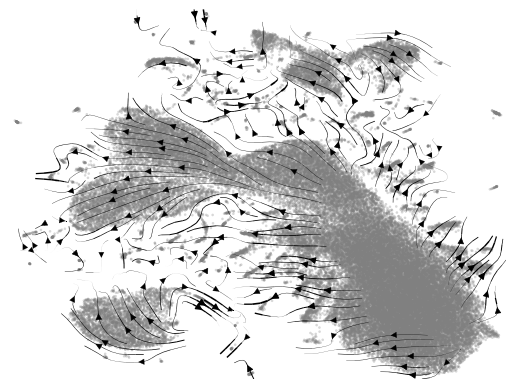

In [23]:
# 2) 近傍グラフ（ないなら）
if "neighbors" not in adata.uns:
    scv.pp.neighbors(adata, n_neighbors=15, n_pcs=40)

# 3) velocity graph（vkeyとxkeyを指定） :contentReference[oaicite:4]{index=4}
scv.tl.velocity_graph(adata, vkey="velocity_ode", xkey="X")

# 4) 埋め込みvelocity作成（umap上の velocity を作る） :contentReference[oaicite:5]{index=5}
scv.tl.velocity_embedding(adata, basis="umap", vkey="velocity_ode")

# 5) stream plot（X_umap と velocity_umap相当を参照） :contentReference[oaicite:6]{index=6}
scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    vkey="velocity_ode",
    color="celltype",
    legend_loc="right margin",
    show=False
)

plt.savefig("/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/compare3condition/velocity_umap.png",
            dpi=300, bbox_inches="tight")
plt.close()

scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    vkey="velocity_ode",
    color="celltype",
    legend_loc="right margin",
    show=False
)

plt.savefig("/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/compare3condition/velocity_umap.png",
            dpi=300, bbox_inches="tight")
plt.close()


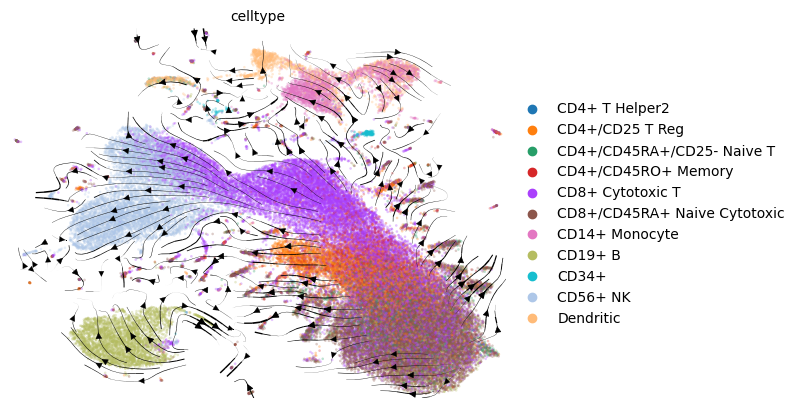

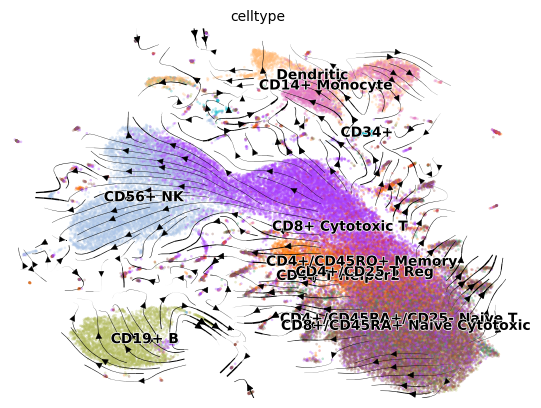

In [ ]:
scv.pl.velocity_embedding_stream(adata, 
                                 basis="umap", 
                                 vkey="velocity_ode",
                                 color='celltype',
                                 legend_loc="right margin",
                                 save="/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/compare3condition/velocity_umap.png")
scv.pl.velocity_embedding_stream(adata, basis="umap", vkey="velocity_ode",color='celltype',legend_loc="on data")

In [29]:
import scvelo as scv
import matplotlib.pyplot as plt

scv.pl.velocity_embedding_stream(
    adata,
    basis="umap",
    vkey="velocity_ode",
    color="celltype",
    legend_loc="right margin",
    show=False
)

plt.savefig("/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/compare3condition/velocity_umap.png",
            dpi=300, bbox_inches="tight")
plt.close()


### make all figs

In [ ]:
import os
import re
import scvelo as scv
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 0) checkpoint_path_dict（そのまま貼ってOK）
# ------------------------------------------------------------
checkpoint_path_dict = {
    "soft_initial": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_174041_soft/20260122_174044_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt",
    "soft_final": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_174041_soft/20260122_174044_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt",
    "hard_initial": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/20260123_013301_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt",
    "hard_final" : "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/20260123_013301_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt",
    "NoConstraintWithModel_initial": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/20260123_024633_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt",
    "NoConstraintWithModel_final": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/20260123_024633_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt",
}

# ------------------------------------------------------------
# 1) keyごとの ode_soft と保存先 root を定義（指定どおり）
# ------------------------------------------------------------
SAVE_ROOTS = {
    "soft": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260122_174041_soft",
    "hard": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard",
    "NoConstraintWithModel": "/home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel",
}

EDGE_TSV = "/home/suzuki/Projects/scDiffusion/external_data/tf_target_edges.tsv"

def _clean_checkpoint_path(s: str) -> str:
    """
    "Loading checkpoint from: /path/to/xxx.pt" みたいな文字列を
    "/path/to/xxx.pt" に直す。
    """
    if s is None:
        return s
    # 最後に出てくる .pt までを拾う
    m = re.search(r"(/[^ ]+?\.pt)\s*$", str(s))
    return m.group(1) if m else str(s).strip()

def _get_condition_and_ode_soft(key: str):
    """
    keyから condition と ode_soft を決める（指定どおり）
    """
    if key.startswith("soft_"):
        return "soft", True
    if key.startswith("hard_"):
        return "hard", False
    if key.startswith("NoConstraintWithModel_"):
        return "NoConstraintWithModel", True
    # 想定外が来ても落とさない
    return "unknown", True

def _plot_and_save_velocity_stream(adata, outpath: str, legend_loc: str):
    """
    scv.pl.velocity_embedding_stream を show=False で描画し、
    plt.savefig で保存して閉じる。
    """
    os.makedirs(os.path.dirname(outpath), exist_ok=True)

    scv.pl.velocity_embedding_stream(
        adata,
        basis="umap",
        vkey="velocity_ode",
        color="celltype",
        legend_loc=legend_loc,
        show=False,
    )
    plt.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close()

# ------------------------------------------------------------
# 2) ここが本体：全checkpointを回す
#    ※ build_and_load_hybrid_model / compute_ode_velocity_layer は既に定義済み前提
#    ※ adata / gene_list / device 等も既に準備済み前提
# ------------------------------------------------------------
reports = {}

for key, ckpt_raw in checkpoint_path_dict.items():
    condition, ode_soft = _get_condition_and_ode_soft(key)
    ckpt = _clean_checkpoint_path(ckpt_raw)

    if condition not in SAVE_ROOTS:
        print(f"[SKIP] Unknown condition for key={key}")
        continue

    save_root = SAVE_ROOTS[condition]
    out_on   = os.path.join(save_root, f"VeloUmap_on_{key}.png")
    out_right = os.path.join(save_root, f"VeloUmap_right_{key}.png")

    print("\n" + "="*80)
    print(f"[{key}] condition={condition} ode_soft={ode_soft}")
    print(f"  checkpoint: {ckpt}")
    print(f"  save_on   : {out_on}")
    print(f"  save_right: {out_right}")

    # (1) model 定義・ロード
    model, rep = build_and_load_hybrid_model(
        checkpoint_path=ckpt,
        gene_list=gene_list,
        edge_tsv_path=EDGE_TSV,
        ode_soft=ode_soft,
        strict=False,
        do_forward_test=True,
        forward_t=0,
        verbose=True,
    )
    reports[key] = rep

    # (2) adata に velocity layer 追記
    compute_ode_velocity_layer(
        adata,
        f=model.ode_model,
        vkey="velocity_ode",
        batch_size=1024,
        clip=None,
    )

    # (3) neighbors / velocity_graph / velocity_embedding
    if "neighbors" not in adata.uns:
        scv.pp.neighbors(adata, n_neighbors=15, n_pcs=40)

    scv.tl.velocity_graph(adata, vkey="velocity_ode", xkey="X")
    scv.tl.velocity_embedding(adata, basis="umap", vkey="velocity_ode")

    # (4) legend_loc 2種類で保存（on data と right margin）
    _plot_and_save_velocity_stream(adata, out_on, legend_loc="on data")
    _plot_and_save_velocity_stream(adata, out_right, legend_loc="right margin")

print("\nDONE. Saved all velocity UMAP stream plots.")



[hard_initial] condition=hard ode_soft=False
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/20260123_013301_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt
  save_on   : /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/VeloUmap_on_hard_initial.png
  save_right: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/VeloUmap_right_hard_initial.png
ODEで使う遺伝子の数779, ODEで使う遺伝子の数1024
[build_and_load_hybrid_model] device=cuda
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/20260123_013301_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt
  state_dict_source: checkpoint(as_state_dict)
  missing_keys: 0, unexpected_keys: 0
  ode_model.W: in_ckpt=True shape_ckpt=(1024, 1024) | in_model=True shape_model=(1024, 1024) | missing=False
  ode_model.b: in_ckpt=True shape_ckpt=(1024,) | in

  0%|          | 0/68579 [00:00<?, ?cells/s]

    finished (0:01:53) --> added 
    'velocity_ode_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:06) --> added
    'velocity_ode_umap', embedded velocity vectors (adata.obsm)

[hard_final] condition=hard ode_soft=False
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/20260123_013301_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt
  save_on   : /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/VeloUmap_on_hard_final.png
  save_right: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/VeloUmap_right_hard_final.png
ODEで使う遺伝子の数779, ODEで使う遺伝子の数1024
[build_and_load_hybrid_model] device=cuda
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_013259_hard/20260123_013301_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt
  state_dict_s

  0%|          | 0/68579 [00:00<?, ?cells/s]

    finished (0:01:55) --> added 
    'velocity_ode_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:09) --> added
    'velocity_ode_umap', embedded velocity vectors (adata.obsm)

[NoConstraintWithModel_initial] condition=NoConstraintWithModel ode_soft=True
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/20260123_024633_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_000000.pt
  save_on   : /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/VeloUmap_on_NoConstraintWithModel_initial.png
  save_right: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/VeloUmap_right_NoConstraintWithModel_initial.png
ODEで使う遺伝子の数779, ODEで使う遺伝子の数1024
[build_and_load_hybrid_model] device=cuda
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructU

  0%|          | 0/68579 [00:00<?, ?cells/s]

    finished (0:01:53) --> added 
    'velocity_ode_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:10) --> added
    'velocity_ode_umap', embedded velocity vectors (adata.obsm)

[NoConstraintWithModel_final] condition=NoConstraintWithModel ode_soft=True
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/20260123_024633_train/checkpoints/pbmc68k_soft_20251127_hvg1024/ema_0.9999_100000.pt
  save_on   : /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/VeloUmap_on_NoConstraintWithModel_final.png
  save_right: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20260123_024631_NoConstraintWithModel/VeloUmap_right_NoConstraintWithModel_final.png
ODEで使う遺伝子の数779, ODEで使う遺伝子の数1024
[build_and_load_hybrid_model] device=cuda
  checkpoint: /home/suzuki/Projects/scDiffusion/work/20260122_1_ReconstructUMAP/20

  0%|          | 0/68579 [00:00<?, ?cells/s]

    finished (0:01:59) --> added 
    'velocity_ode_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:09) --> added
    'velocity_ode_umap', embedded velocity vectors (adata.obsm)

DONE. Saved all velocity UMAP stream plots.
